In [1]:
# %reload_ext autoreload
# %autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

#Seed 1 ok with vision 1/3, 2/3, width_min 45  width_max 80, clip -1.0, 2.5 perfect on the banana
#Prmts:
#Width threshold for obstacle detection 
#Vision threshold to only keep center vision 

#Seed 67 ok with vision 1/3, 2/3, width_min 45  width_max 80, clip -1.0, 2.5 perfect on the banana


# exam seed 1, 67, 777
sim = MiniprojectSimulation(level=2, seed=777)
controller = Controller(sim)

for _ in trange(70000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()
    
controller.close()
sim.renderer.show_in_notebook()

100%|██████████| 70000/70000 [01:27<00:00, 802.05it/s] 


Saved video: raw_vision


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


final dist 12.790295169212204


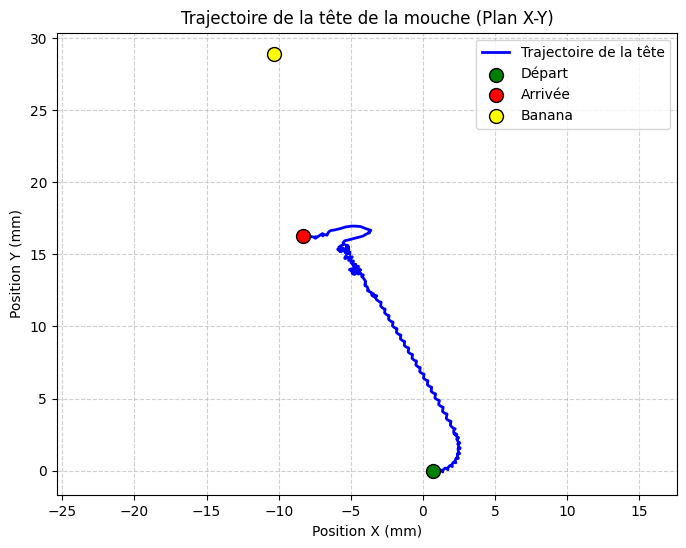

In [2]:
controller.plot_head_trajectory()


In [2]:
print(sim.world.banana_xy)

(np.float64(-10.355681357019149), np.float64(28.906774050637956))


In [1]:
import numpy as np
import tqdm
from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

MAX_NUM_STEPS = 70000
NUM_SEEDS = 10
LEVEL = 2  # change as needed
SUCCESS_RADIUS = 3.0

def run_single_seed(seed):
    sim = MiniprojectSimulation(level=LEVEL, seed=seed, back_cam=False, top_cam=False)
    controller = Controller(sim)

    def get_distance():
        fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
        banana_xy = np.array(sim.world.banana_xy)
        #print("banana",banana_xy)
        return np.linalg.norm(fly_xy - banana_xy)

    for step in range(MAX_NUM_STEPS):
        dist = get_distance()
        if dist <= SUCCESS_RADIUS:
            print(f"  seed={seed} → reached banana in {step} steps (dist={dist:.2f})")
            print("banana pos",sim.world.banana_xy)
            return dist

        joint_angles, adhesion_signals = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion_signals)
        sim.step()

    final_dist = get_distance()
    print(f"  seed={seed} → timed out (final dist={final_dist:.2f})")
    return final_dist


distances = []
#seeds = np.random.randint(0, 101, size=NUM_SEEDS)
seeds=[7]
# for seed in tqdm.tqdm(seeds):
#     d = run_single_seed(int(seed))
#     distances.append(d)
d=run_single_seed(1)
distances.append(d)

distances = np.array(distances)
print(f"\n--- Results over {NUM_SEEDS} seeds ---")
print(f"  Mean final distance : {distances.mean():.2f}")
print(f"  Std                 : {distances.std():.2f}")
print(f"  Min / Max           : {distances.min():.2f} / {distances.max():.2f}")
print(f"  Success rate (≤{SUCCESS_RADIUS}mm): {(distances <= SUCCESS_RADIUS).mean()*100:.0f}%")

OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'


  seed=1 → reached banana in 61001 steps (dist=3.00)
banana pos (np.float64(-16.675396636978267), np.float64(-23.91126942978231))

--- Results over 10 seeds ---
  Mean final distance : 3.00
  Std                 : 0.00
  Min / Max           : 3.00 / 3.00
  Success rate (≤3.0mm): 100%
